### 타이타닉 생존자 예측 예제(MLP)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

In [ ]:
# 1. 데이터 로드
train_df = pd.read_csv("dataset/train_titanic.csv")
test_df = pd.read_csv("dataset/test_titanic.csv")

In [ ]:
# 1.1 전처리 전 데이터 확인
print("=== 전처리 전 데이터 (train_df) ===")
print(train_df.head())
print("\n=== 데이터 기본 정보 ===")
print(train_df.info())
print("\n=== 결측값 수 ===")
print(train_df.isnull().sum())

=== 전처리 전 데이터 (train_df) ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


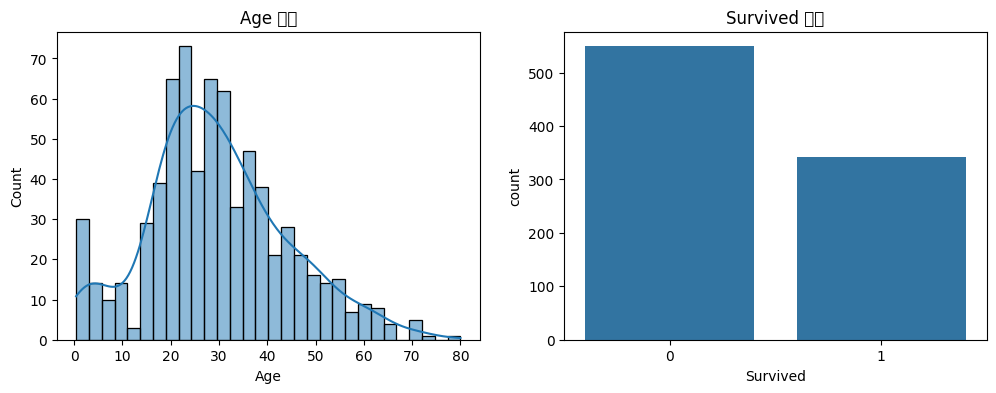

In [ ]:
# 주요 특성 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True)
plt.title('Age 분포')
plt.subplot(1, 2, 2)
sns.countplot(x='Survived', data=train_df)
plt.title('Survived 분포')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


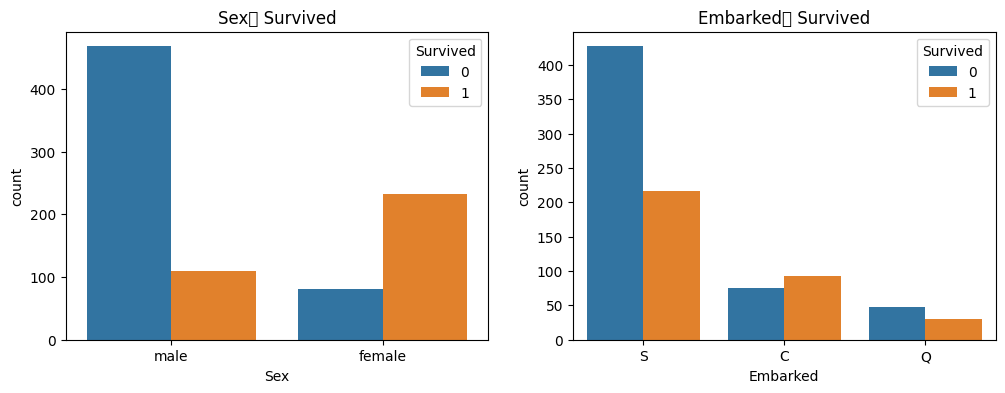

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.title('Sex별 Survived')
plt.subplot(1, 2, 2)
sns.countplot(x='Embarked', hue='Survived', data=train_df)
plt.title('Embarked별 Survived')
plt.show()

In [ ]:
# 2. 데이터 전처리
# 결측값 처리
train_df = train_df.assign(Age=train_df['Age'].fillna(train_df['Age'].median()))
test_df = test_df.assign(Age=test_df['Age'].fillna(test_df['Age'].median()))
train_df = train_df.assign(Embarked=train_df['Embarked'].fillna(train_df['Embarked'].mode()[0]))
test_df = test_df.assign(Fare=test_df['Fare'].fillna(test_df['Fare'].median()))

In [ ]:
# 특징 선택
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_train = train_df[features]
y_train = train_df['Survived']
X_test = test_df[features]

In [ ]:
# 3. 원핫 인코딩
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_features_train = ohe.fit_transform(X_train[['Sex', 'Embarked']])
cat_feature_names = ohe.get_feature_names_out(['Sex', 'Embarked'])
cat_features_test = ohe.transform(X_test[['Sex', 'Embarked']])

In [ ]:
# 연속형 데이터
num_features_train = X_train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
num_features_test = X_test[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
scaler = StandardScaler()
num_features_train_scaled = scaler.fit_transform(num_features_train)
num_features_test_scaled = scaler.transform(num_features_test)

In [ ]:
# 데이터 결합
X_train_combined = np.hstack([num_features_train_scaled, cat_features_train])
X_test_combined = np.hstack([num_features_test_scaled, cat_features_test])

In [ ]:
# 3.1 원핫 인코딩 후 데이터 확인
X_train_combined_df = pd.DataFrame(X_train_combined, columns=list(num_features_train.columns) + list(cat_feature_names))
print("\n=== 원핫 인코딩 후 데이터 (train) ===")
print(X_train_combined_df.head())
print("\n=== 원핫 인코딩 후 특성 수 ===")
print(f"특성 수: {X_train_combined.shape[1]}")


=== 원핫 인코딩 후 데이터 (train) ===
     Pclass       Age     SibSp     Parch      Fare  Sex_female  Sex_male  \
0  0.827377 -0.565736  0.432793 -0.473674 -0.502445         0.0       1.0   
1 -1.566107  0.663861  0.432793 -0.473674  0.786845         1.0       0.0   
2  0.827377 -0.258337 -0.474545 -0.473674 -0.488854         1.0       0.0   
3 -1.566107  0.433312  0.432793 -0.473674  0.420730         1.0       0.0   
4  0.827377  0.433312 -0.474545 -0.473674 -0.486337         0.0       1.0   

   Embarked_C  Embarked_Q  Embarked_S  
0         0.0         0.0         1.0  
1         1.0         0.0         0.0  
2         0.0         0.0         1.0  
3         0.0         0.0         1.0  
4         0.0         0.0         1.0  

=== 원핫 인코딩 후 특성 수 ===
특성 수: 10


In [ ]:
# 4. PCA 적용
pca = PCA(n_components=0.95)  # 95% 분산 유지
X_train_pca = pca.fit_transform(X_train_combined)
X_test_pca = pca.transform(X_test_combined)

In [ ]:
# 4.1 PCA 적용 후 데이터 확인
print("\n=== PCA 적용 후 데이터 (train) ===")
print(pd.DataFrame(X_train_pca).head())
print("\n=== PCA 후 특성 수 ===")
print(f"특성 수: {X_train_pca.shape[1]}")
print("\n=== PCA 설명된 분산 비율 ===")
print(pca.explained_variance_ratio_)


=== PCA 적용 후 데이터 (train) ===
          0         1         2         3         4         5         6
0  1.189309  0.192409 -0.110413  0.659347 -0.288647 -0.084718  0.192395
1 -1.928325 -0.283466 -0.261757  0.478090  1.101178  0.310490 -0.695613
2  0.952821 -0.283762 -0.244249 -0.375087  0.717514  0.471797  0.655214
3 -1.477304 -0.221825 -0.097151  0.492243  1.142331 -0.463277  0.425057
4  0.884103 -0.794282  0.416630  0.052776 -0.452524  0.185091  0.287513

=== PCA 후 특성 수 ===
특성 수: 7

=== PCA 설명된 분산 비율 ===
[0.29349319 0.28200411 0.12503667 0.1013726  0.06904592 0.06537826
 0.04703816]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

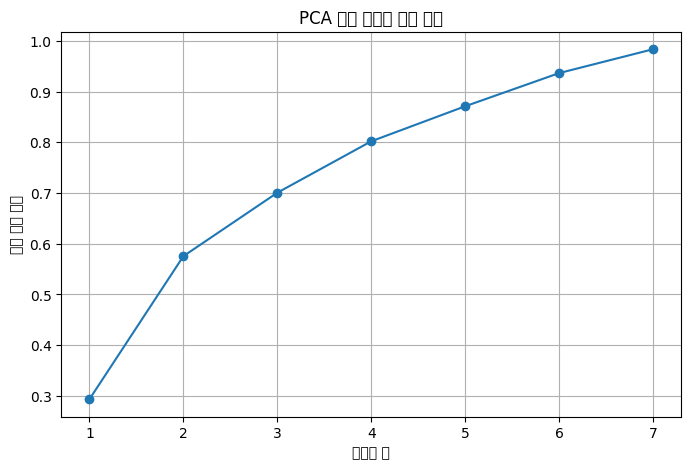

In [ ]:
# PCA 설명된 분산 비율 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('PCA 누적 설명된 분산 비율')
plt.xlabel('주성분 수')
plt.ylabel('누적 분산 비율')
plt.grid(True)
plt.show()

In [ ]:
# 5. MLP 모델 구성
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# 6. 학습
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_pca, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4198 - loss: 0.7543 - val_accuracy: 0.3743 - val_loss: 0.7012
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4799 - loss: 0.7126 - val_accuracy: 0.6816 - val_loss: 0.6588
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6211 - loss: 0.6774 - val_accuracy: 0.7709 - val_loss: 0.6250
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6556 - loss: 0.6470 - val_accuracy: 0.7989 - val_loss: 0.5906
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6861 - loss: 0.6335 - val_accuracy: 0.7877 - val_loss: 0.5559
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7332 - loss: 0.5958 - val_accuracy: 0.7933 - val_loss: 0.5234
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7467 - loss: 0.5671 - val_accuracy: 0.7933 - val_loss: 0.4961
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7338 - loss: 0.5620 - val_accuracy: 0.8045 - val_loss

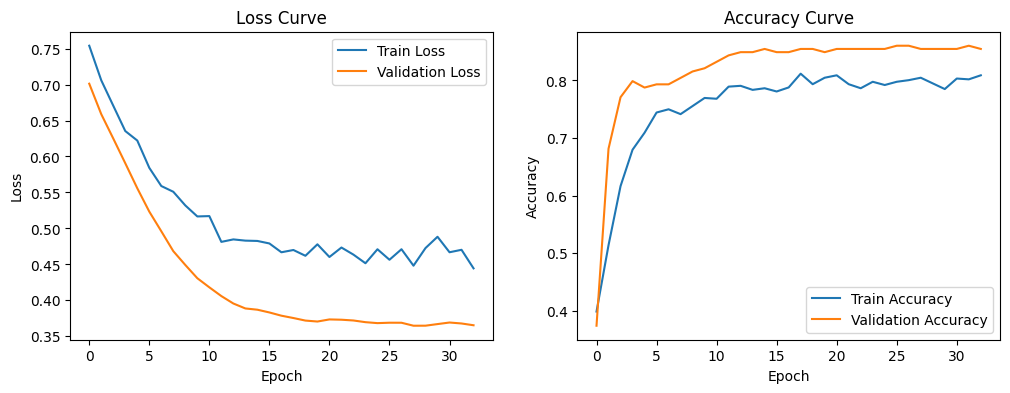

In [ ]:
# 7. 학습 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 8. 테스트 데이터 예측
y_pred = (model.predict(X_test_pca) > 0.5).astype(int).flatten() # sigmoid 출력이 0.5 이상이면 True(생존, 1), 0.5 미만이면 False(사망, 0)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# 예측 결과 저장
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': y_pred
})
submission.to_csv('./dataset/submission.csv', index=False)
print("\n=== 예측 결과 상위 5개 ===")
print(submission.head())


=== 예측 결과 상위 5개 ===
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
